In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split

In [ ]:

# Load data
input_path = "../data/processed/BRFSS_Diabetes_MedicalOnly.csv"
output_path = "../data/processed/BRFSS_Diabetes_Relevant_Features.csv"

df = pd.read_csv(input_path)

# Define selected features + target
selected_features = [
    'age_score',
    'BMI',
    '_RFHYPE5',
    '_RFHLTH',
    'med_conditions_score',
    'cv_risk_score',
    'meets_aerobic_guidelines',
    'current_smoker',
    'alcohol_level',
    'diet_score',
    'low_ses_flag',
    'income_score',
    'edu_score',
    'has_arthritis',
    'SEX',
    'care_access_score',
    'strength_freq_weekly',
    '_CHOLCHK'
]

target = 'HasDiabetes'

# Ensure all selected features and target exist
available_features = [col for col in selected_features if col in df.columns]
if target not in df.columns:
    raise ValueError(f"Target column '{target}' not found in dataset.")

# Create new dataframe
df_selected = df[available_features + [target]].copy()

# Optional: Drop rows with missing values in selected features
df_selected = df_selected.dropna(subset=available_features + [target])

print(f"Selected {len(available_features)} features + target.")
print("Features:", available_features)
print(f"Final dataset shape: {df_selected.shape}")

# Save
df_selected.to_csv(output_path, index=False)
print(f"Saved to {output_path}")

Selected 18 features + target.
Features: ['age_score', 'BMI', '_RFHYPE5', '_RFHLTH', 'med_conditions_score', 'cv_risk_score', 'meets_aerobic_guidelines', 'current_smoker', 'alcohol_level', 'diet_score', 'low_ses_flag', 'income_score', 'edu_score', 'has_arthritis', 'SEX', 'care_access_score', 'strength_freq_weekly', '_CHOLCHK']
Final dataset shape: (351758, 19)
Saved to ../data/processed/BRFSS_Diabetes_Relevant_Features.csv


Dataset shape: (351758, 19)

Null values per column:
age_score                   0
BMI                         0
_RFHYPE5                    0
_RFHLTH                     0
med_conditions_score        0
cv_risk_score               0
meets_aerobic_guidelines    0
current_smoker              0
alcohol_level               0
diet_score                  0
low_ses_flag                0
income_score                0
edu_score                   0
has_arthritis               0
SEX                         0
care_access_score           0
strength_freq_weekly        0
_CHOLCHK                    0
HasDiabetes                 0
dtype: int64

Numerical features (18): ['age_score', 'BMI', '_RFHYPE5', '_RFHLTH', 'med_conditions_score', 'cv_risk_score', 'meets_aerobic_guidelines', 'current_smoker', 'alcohol_level', 'diet_score', 'low_ses_flag', 'income_score', 'edu_score', 'has_arthritis', 'SEX', 'care_access_score', 'strength_freq_weekly', '_CHOLCHK']
Binary/Categorical features (0): []


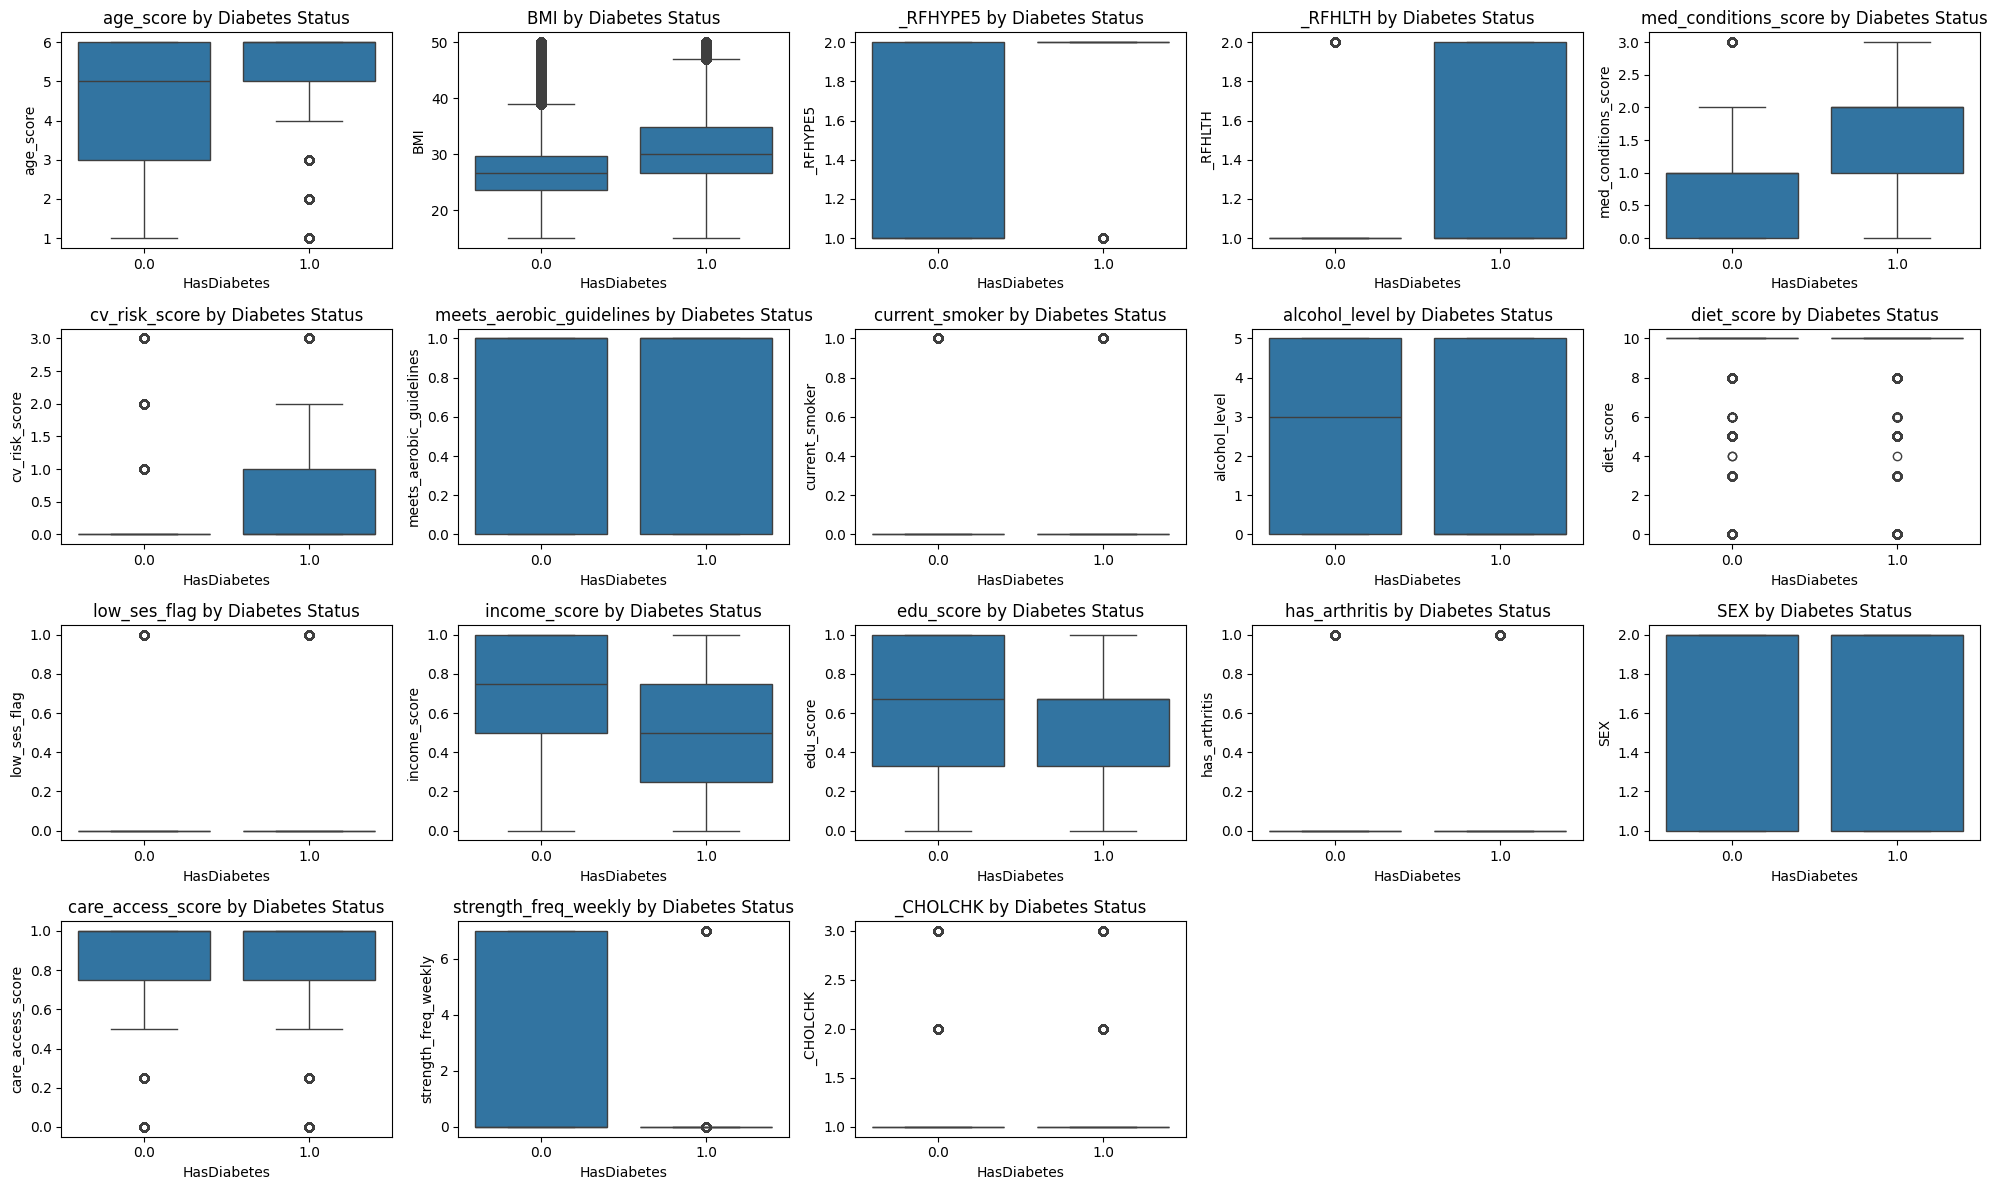

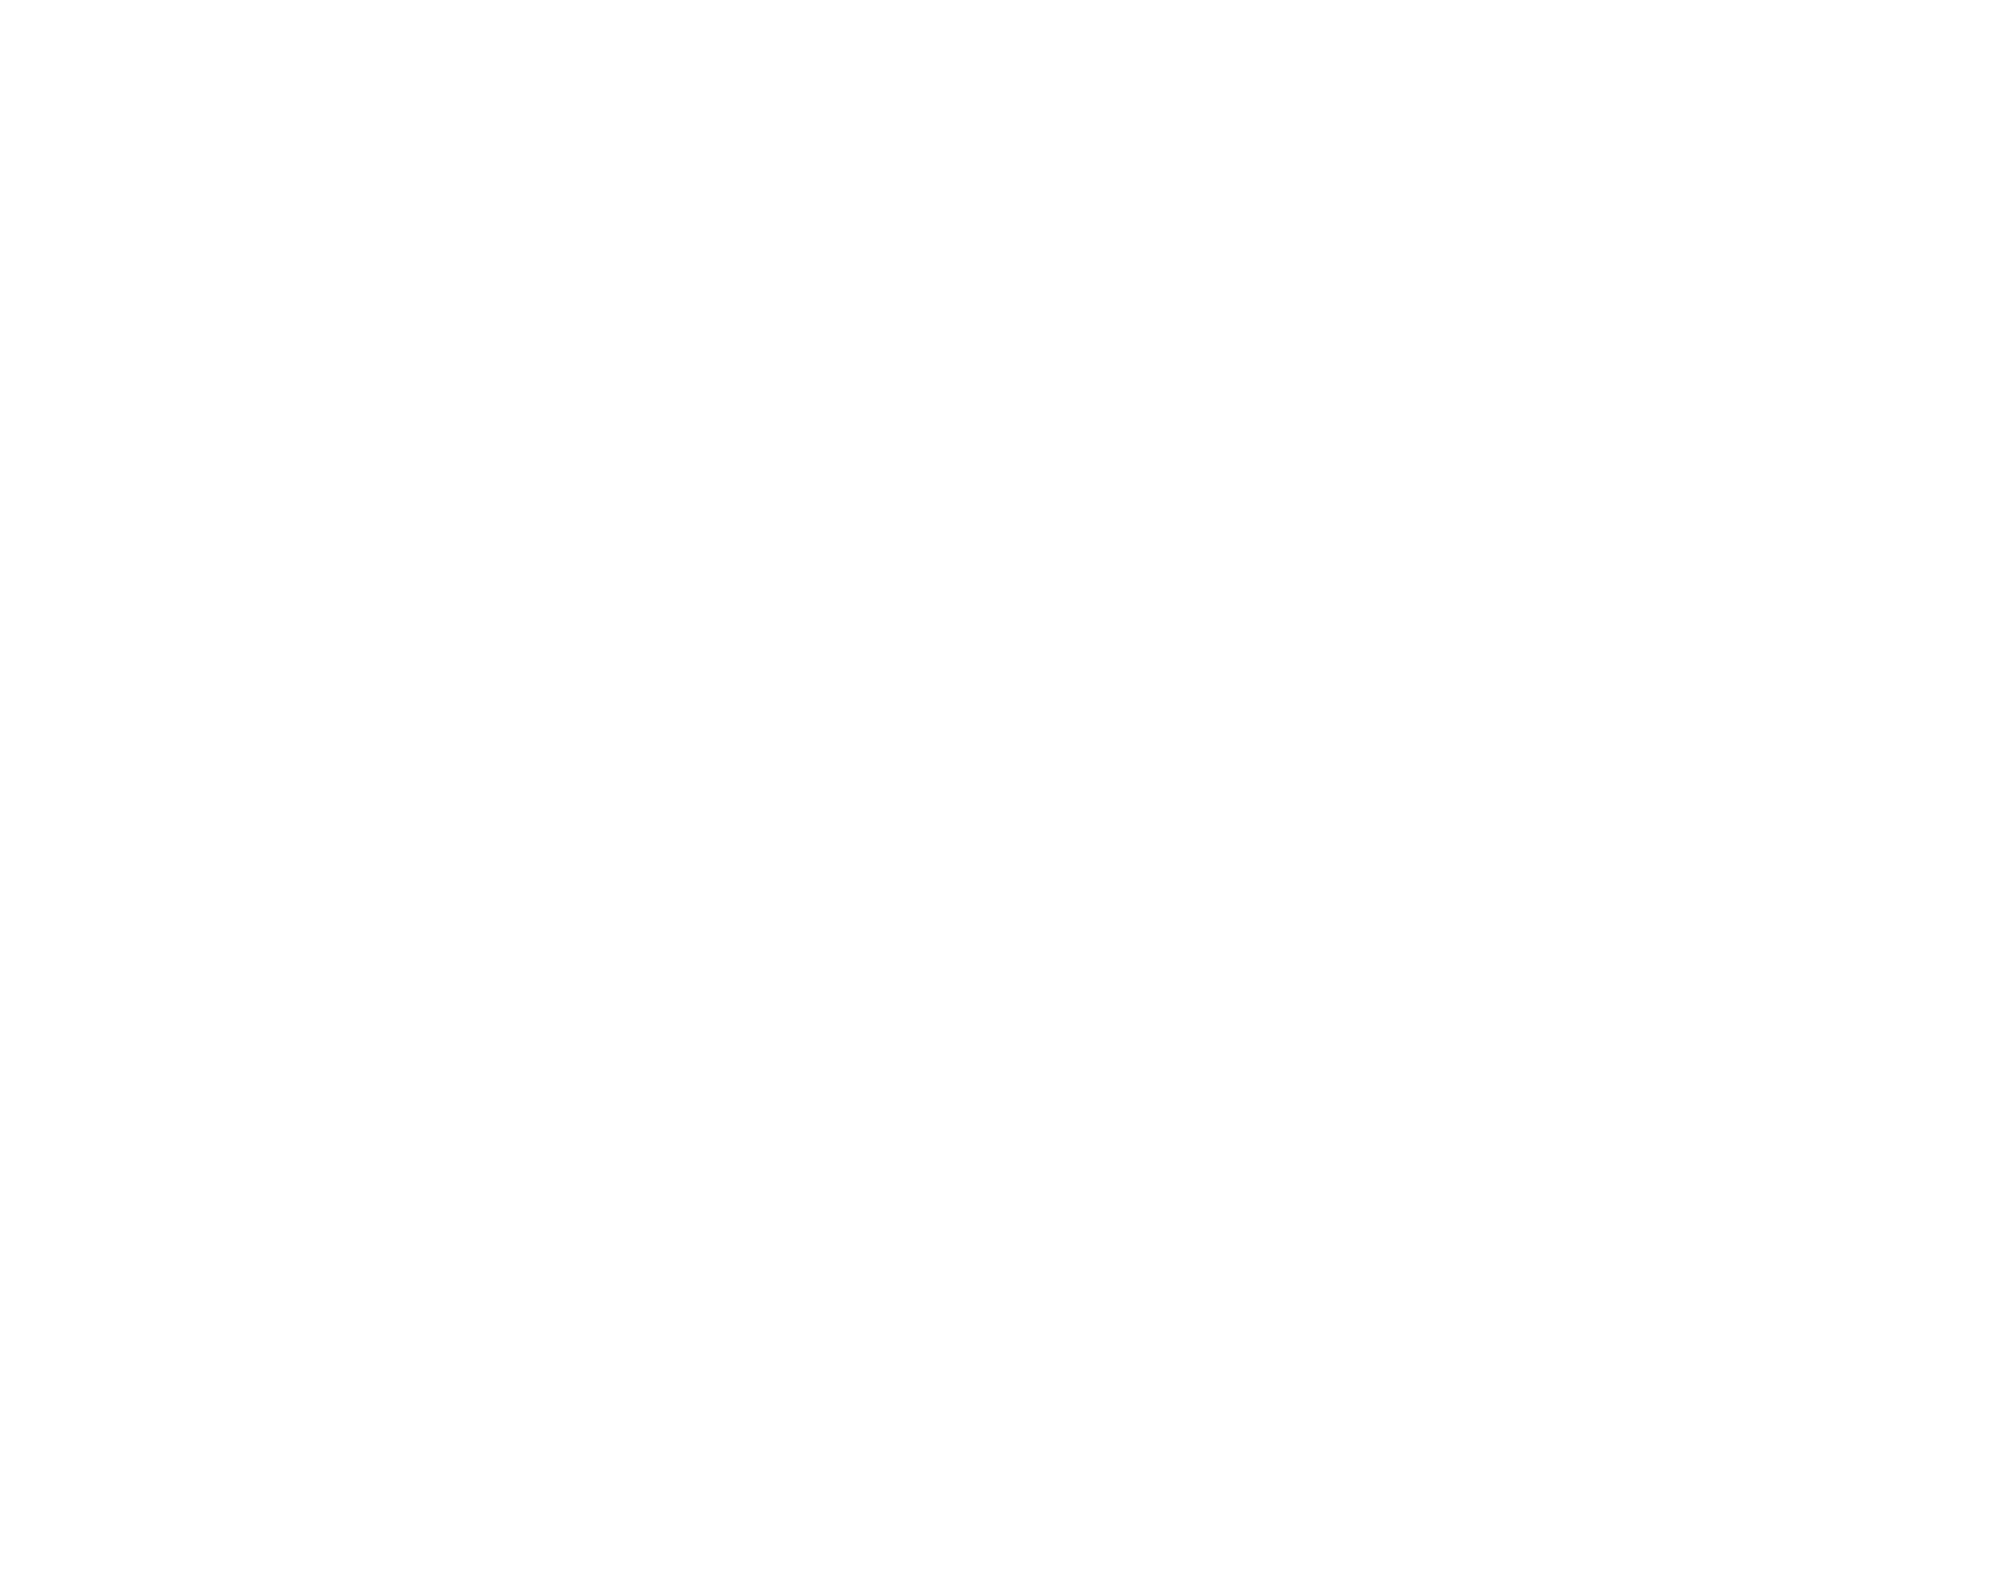


=== Numerical Feature Summary (by Diabetes Status) ===
HasDiabetes                0.0            1.0
age_score count  175127.000000  176631.000000
          mean        4.297150       5.233526
          std         1.547097       0.996766
          min         1.000000       1.000000
          25%         3.000000       5.000000
...                        ...            ...
_CHOLCHK  min         1.000000       1.000000
          25%         1.000000       1.000000
          50%         1.000000       1.000000
          75%         1.000000       1.000000
          max         3.000000       3.000000

[144 rows x 2 columns]


In [6]:

# Load the selected features dataset
df = pd.read_csv("../data/processed/BRFSS_Diabetes_Relevant_Features.csv")

print("Dataset shape:", df.shape)
print("\nNull values per column:")
print(df.isnull().sum())

# Identify numerical vs binary/categorical
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
# Remove target if it's in numerical
if 'HasDiabetes' in numerical_cols:
    numerical_cols.remove('HasDiabetes')

binary_cols = [col for col in df.columns if col not in numerical_cols and col != 'HasDiabetes']

print(f"\nNumerical features ({len(numerical_cols)}): {numerical_cols}")
print(f"Binary/Categorical features ({len(binary_cols)}): {binary_cols}")

# --- Visualizations ---
plt.figure(figsize=(20, 12))

# Boxplots for numerical features
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(4, 5, i)
    sns.boxplot(data=df, y=col, x='HasDiabetes')
    plt.title(f'{col} by Diabetes Status')

# Hide empty subplots
for j in range(i+1, 20):
    plt.subplot(4, 5, j)
    plt.axis('off')

plt.tight_layout()
plt.show()

# --- Distribution of binary features ---
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for idx, col in enumerate(binary_cols[:16]):  # plot first 16 binary
    sns.countplot(data=df, x=col, hue='HasDiabetes', ax=axes[idx])
    axes[idx].set_title(f'{col}')
    axes[idx].tick_params(axis='x', rotation=45)

# Hide extra subplots
for j in range(len(binary_cols), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

# --- Summary stats for numerical features ---
print("\n=== Numerical Feature Summary (by Diabetes Status) ===")
print(df.groupby('HasDiabetes')[numerical_cols].describe().T)

In [7]:
binary_features = [
    'meets_aerobic_guidelines',
    'current_smoker',
    'low_ses_flag',
    'has_arthritis'
]

# The rest are continuous or ordinal (treat as numerical)
continuous_features = [
    'age_score', 'BMI', 'med_conditions_score', 'cv_risk_score',
    'alcohol_level', 'diet_score', 'income_score', 'edu_score',
    'care_access_score', 'strength_freq_weekly'
]

# Special recoded BRFSS variables (ordinal, but often treated as categorical or numerical)
# We'll keep them in continuous for correlation, but note they're discrete
brfss_ordinal = ['_RFHYPE5', '_RFHLTH', '_CHOLCHK', 'SEX']

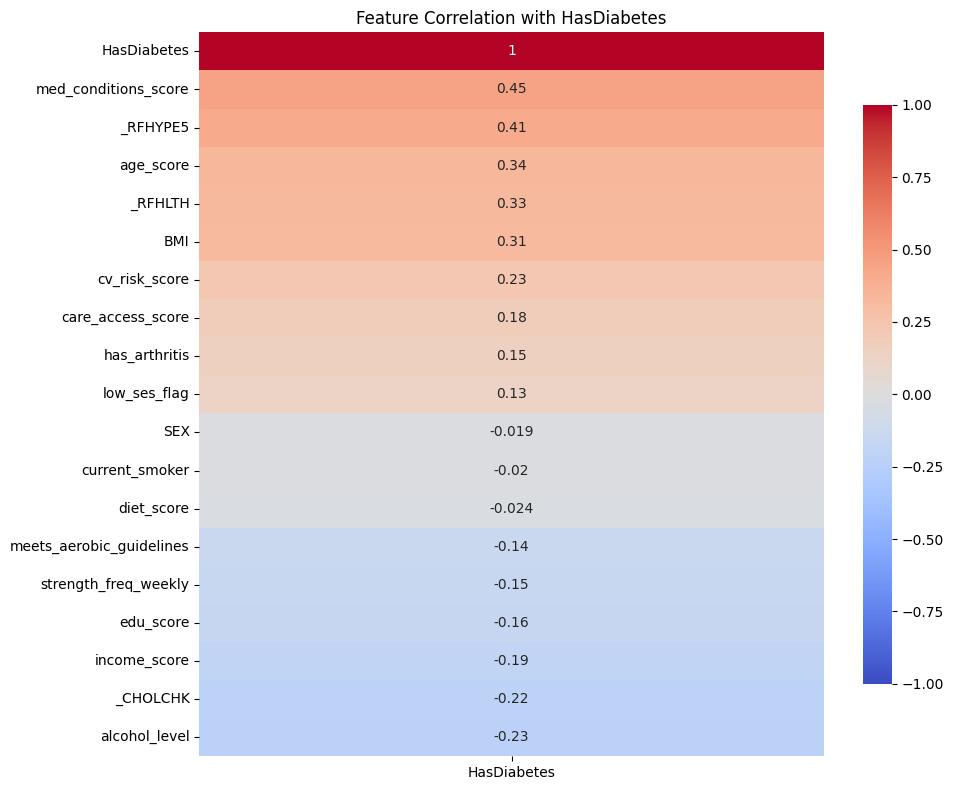

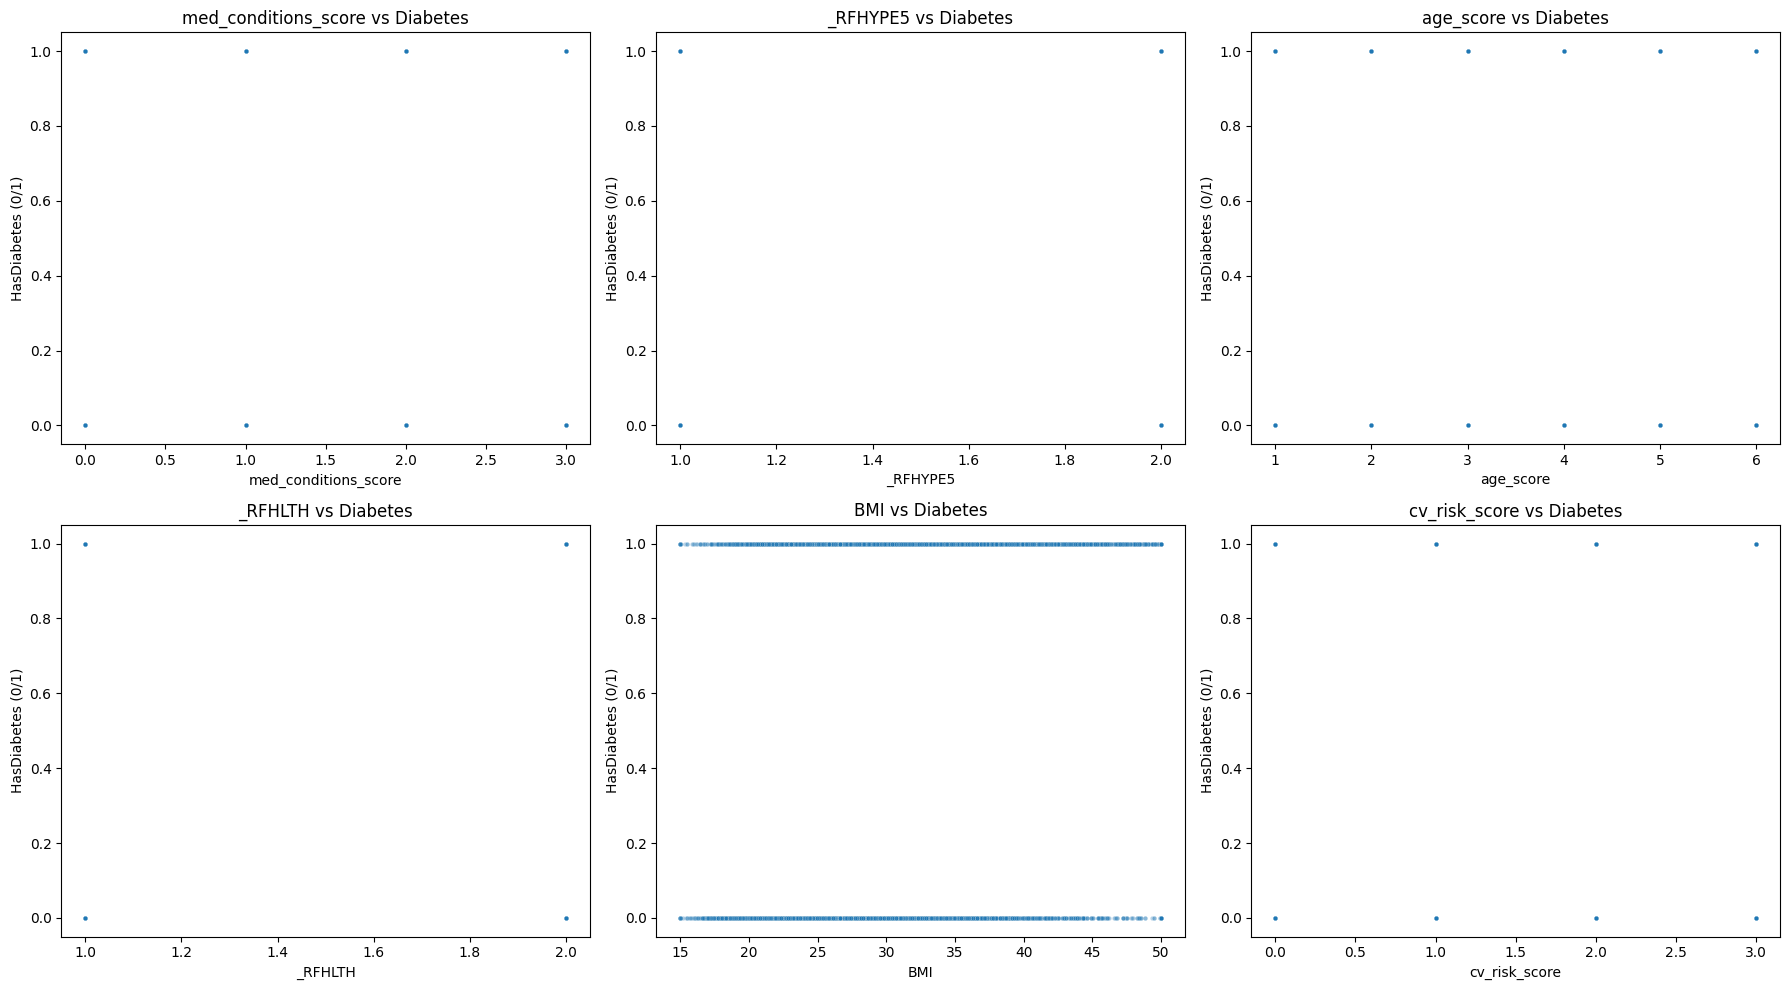

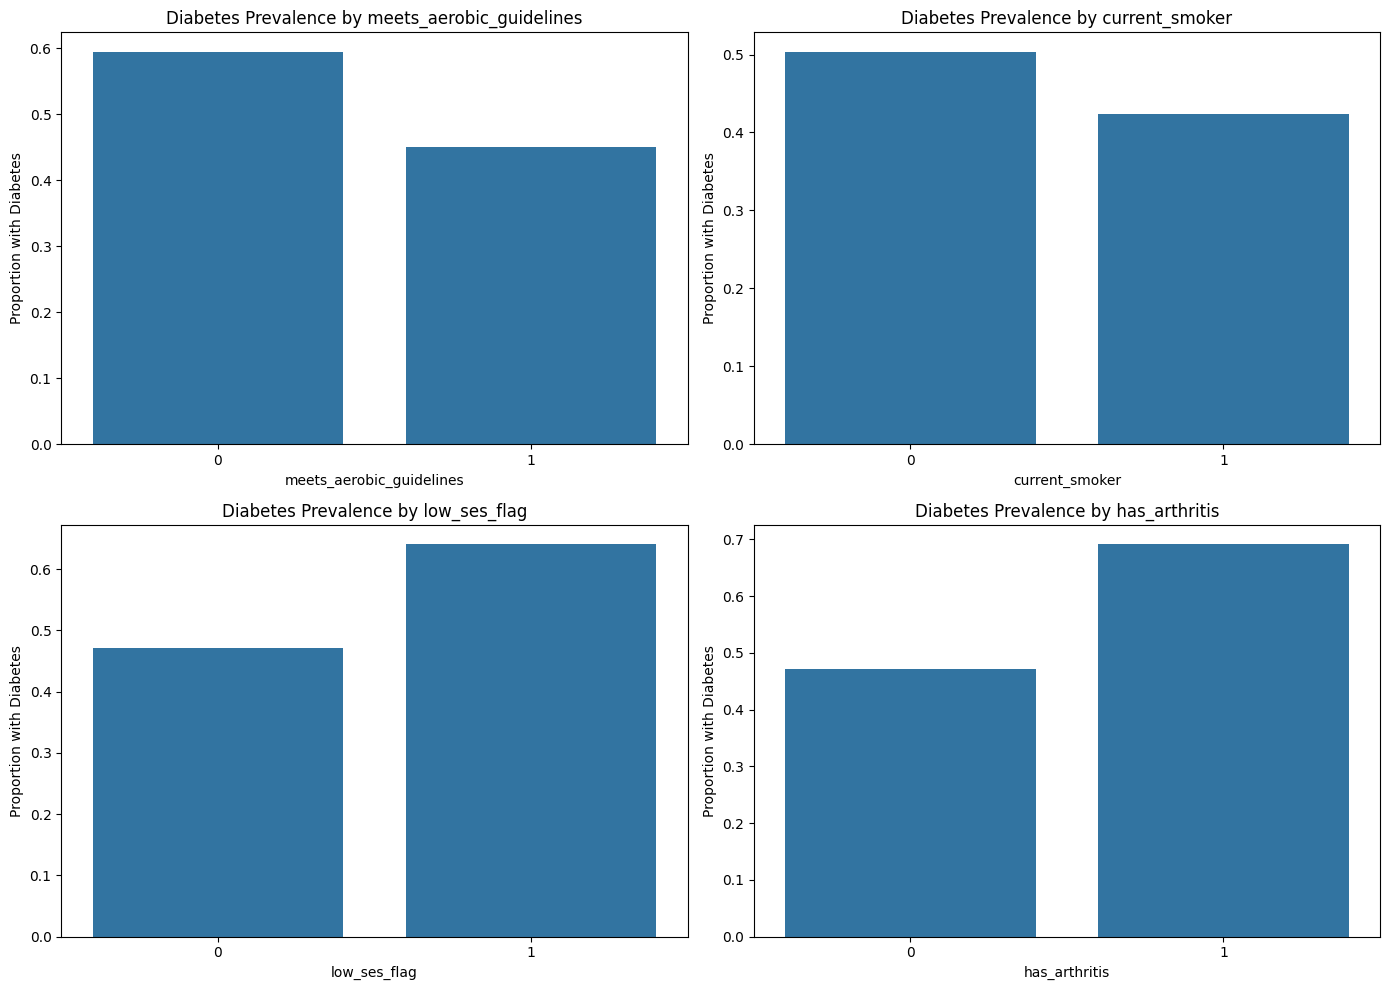

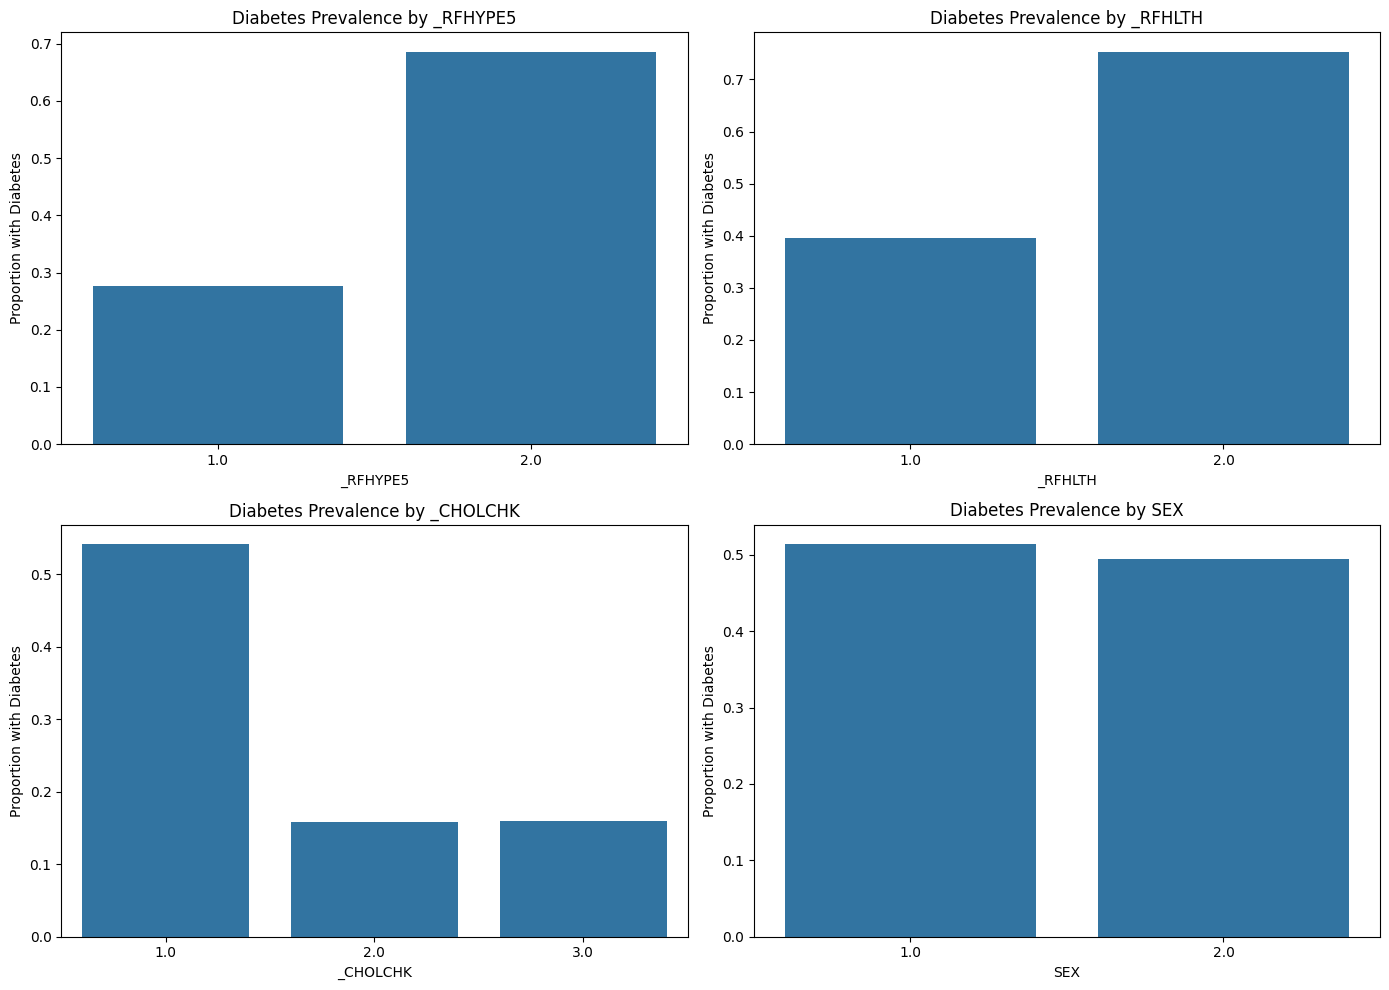

In [ ]:

# Load data
df = pd.read_csv("../data/processed/BRFSS_Diabetes_Relevant_Features.csv")

# Define binary features (0/1 indicators)
binary_features = [
    'meets_aerobic_guidelines',
    'current_smoker',
    'low_ses_flag',
    'has_arthritis'
]

# All other non-target features are treated as numerical/continuous
numerical_features = [col for col in df.columns if col not in binary_features and col != 'HasDiabetes']

# HEATMAP: Correlation with target

plt.figure(figsize=(10, 8))
# Compute correlation matrix
corr = df.corr()[['HasDiabetes']].sort_values(by='HasDiabetes', ascending=False)
# Plot heatmap
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1, cbar_kws={'shrink': 0.8})
plt.title('Feature Correlation with HasDiabetes')
plt.tight_layout()
plt.show()

# SCATTER PLOTS (with jitter or boxplots) for top numerical features

# Get top 6 numerical features by absolute correlation with target
top_numerical = corr.drop('HasDiabetes').abs().sort_values(by='HasDiabetes', ascending=False).head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(top_numerical):
    # Use scatter with transparency + jitter for large data
    ax = axes[i]
    # Add small jitter to y for visibility (optional)
    sns.scatterplot(
        data=df.sample(frac=0.05, random_state=42),  # sample 5% for speed/clarity
        x=col,
        y='HasDiabetes',
        alpha=0.3,
        s=10,
        ax=ax
    )
    # Or use boxplot (often clearer for binary target)
    # sns.boxplot(data=df, x='HasDiabetes', y=col, ax=ax)
    ax.set_title(f'{col} vs Diabetes')
    ax.set_ylabel('HasDiabetes (0/1)')

plt.tight_layout()
plt.show()

# BAR PLOTS: Diabetes prevalence by binary features

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(binary_features):
    # Compute diabetes rate per category
    diag_rate = df.groupby(col)['HasDiabetes'].mean().reset_index()
    sns.barplot(data=diag_rate, x=col, y='HasDiabetes', ax=axes[i])
    axes[i].set_title(f'Diabetes Prevalence by {col}')
    axes[i].set_ylabel('Proportion with Diabetes')
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

# BRFSS ordinal features as categorical bar plots

brfss_ordinal = ['_RFHYPE5', '_RFHLTH', '_CHOLCHK', 'SEX']
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(brfss_ordinal):
    diag_rate = df.groupby(col)['HasDiabetes'].mean().reset_index()
    sns.barplot(data=diag_rate, x=col, y='HasDiabetes', ax=axes[i])
    axes[i].set_title(f'Diabetes Prevalence by {col}')
    axes[i].set_ylabel('Proportion with Diabetes')
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

In [10]:

# Load the cleaned dataset
input_path = '../data/processed/BRFSS_Diabetes_Relevant_Features.csv'
df = pd.read_csv(input_path)
print(f"Loaded dataset: {df.shape[0]:,} rows, {df.shape[1]} columns")

# Define target and features
target = 'HasDiabetes'
features = [col for col in df.columns if col != target]

# Split features and target
X = df[features]
y = df[target]

# Perform train-test split (80-20 split, stratified to maintain class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Combine features and target back into DataFrames
train_df = pd.concat([X_train.reset_index(drop=True), y_train.reset_index(drop=True)], axis=1)
test_df = pd.concat([X_test.reset_index(drop=True), y_test.reset_index(drop=True)], axis=1)

# Create output directory
output_dir = '../data/train-test/'
os.makedirs(output_dir, exist_ok=True)

# Save preprocessed train and test sets
train_df.to_csv(os.path.join(output_dir, 'train_set.csv'), index=False)
test_df.to_csv(os.path.join(output_dir, 'test_set.csv'), index=False)

# Print diagnostics
print(f"\nTrain set shape: {train_df.shape}")
print(f"Test set shape: {test_df.shape}")

print(f"\nTrain class distribution:")
print((y_train.value_counts(normalize=True) * 100).map('{:.2f}%'.format))

print(f"\nTest class distribution:")
print((y_test.value_counts(normalize=True) * 100).map('{:.2f}%'.format))

print(f"\nTrain and test sets saved to:")
print(f"   {os.path.join(output_dir, 'train_set.csv')}")
print(f"   {os.path.join(output_dir, 'test_set.csv')}")



Loaded dataset: 351,758 rows, 19 columns

Train set shape: (281406, 19)
Test set shape: (70352, 19)

Train class distribution:
HasDiabetes
1.0    50.21%
0.0    49.79%
Name: proportion, dtype: object

Test class distribution:
HasDiabetes
1.0    50.21%
0.0    49.79%
Name: proportion, dtype: object

Train and test sets saved to:
   ../data/train-test/train_set.csv
   ../data/train-test/test_set.csv
